# WS6-200 Frequency Log Plotter

Visualise data saved by `monitor.py --log` or `lock.py --log`.

Two CSV formats are supported automatically:
- **Monitor log** (`wlm_*.csv`): columns `time_ns`, `frequency_THz`
- **Lock log** (`lock_*.csv`): columns `time_s`, `frequency_THz`, `error_MHz`, `integrator_V`, `output_V`, `saturated`


## 1. Imports

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

## 2. Load CSV log

In [ ]:
import glob

# ── Find the most recent log file, or override manually ──────────────────────
_logs = sorted(glob.glob("logs/**/*.csv", recursive=True))
LOG_FILE = _logs[-1] if _logs else "run_001.csv"   # override: LOG_FILE = "path/to/file.csv"
SETPOINT_THz = 298.002634         # ~1006 nm — measured free-running frequency; set to None to skip deviation plots
# ─────────────────────────────────────────────────────────────────────────────

print(f"Loading: {LOG_FILE}")
assert os.path.isfile(LOG_FILE), f"File not found: {LOG_FILE!r}"

df = pd.read_csv(LOG_FILE)

# ── Normalise time column ─────────────────────────────────────────────────────
if "time_ns" in df.columns:
    # monitor.py log: nanosecond timestamps → elapsed seconds
    df["time_s"] = (df["time_ns"] - df["time_ns"].iloc[0]) * 1e-9
    IS_LOCK_LOG = False
elif "time_s" in df.columns:
    # lock.py log: time_s already elapsed
    IS_LOCK_LOG = True
else:
    raise ValueError("CSV has neither 'time_ns' nor 'time_s' column.")

# ── Frequency deviation ───────────────────────────────────────────────────────
if "error_MHz" in df.columns:
    # Lock log already contains the error signal
    df["deviation_MHz"] = df["error_MHz"]
elif SETPOINT_THz is not None:
    df["deviation_MHz"] = (df["frequency_THz"] - SETPOINT_THz) * 1e6

# ── Derived sample rate ───────────────────────────────────────────────────────
dt_s = np.diff(df["time_s"].values)
df_rate = pd.DataFrame({
    "time_s": df["time_s"].values[1:],
    "rate_Hz": 1.0 / dt_s,
})

print(f"Log type       : {'Lock log' if IS_LOCK_LOG else 'Monitor log'}")
print(f"Samples        : {len(df):,}")
print(f"Duration       : {df['time_s'].iloc[-1]:.2f} s")
print(f"Mean rate      : {1/dt_s.mean():.1f} Hz")
print(f"Mean frequency : {df['frequency_THz'].mean():.6f} THz")
if "deviation_MHz" in df.columns:
    print(f"Mean deviation : {df['deviation_MHz'].mean():+.3f} MHz")
    print(f"Std  deviation : {df['deviation_MHz'].std():.3f} MHz")


Loading: logs/2026-05-22/wlm_14-21-14.csv
Log type       : Monitor log
Samples        : 14,899
Duration       : 8.30 s
Mean rate      : 1794.2 Hz
Mean frequency : 298.004400 THz
Mean deviation : +0.043 MHz
Std  deviation : 1.066 MHz


## 3 & 4. Plots

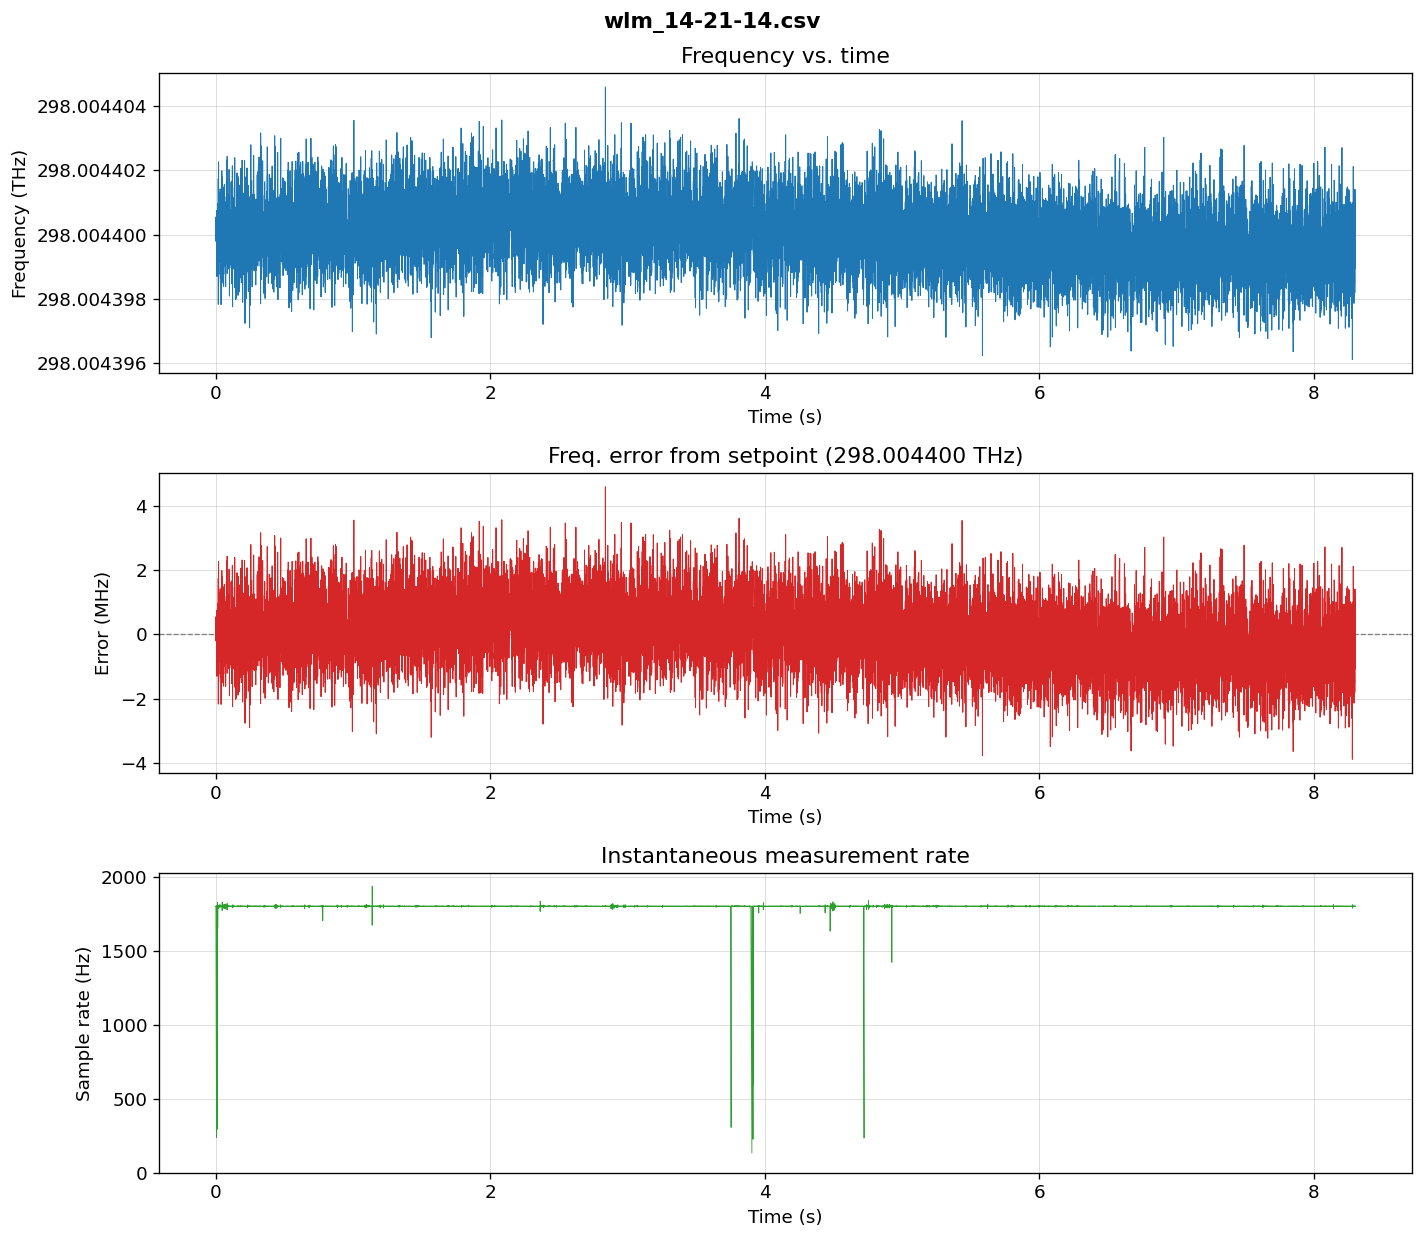

In [13]:
has_deviation = "deviation_MHz" in df.columns
has_piezo     = IS_LOCK_LOG and "output_V" in df.columns

n_panels = 1 + has_deviation + 1 + has_piezo   # freq, [deviation], rate, [piezo]
fig, axes = plt.subplots(n_panels, 1, figsize=(12, 3.5 * n_panels), sharex=False)
if n_panels == 1:
    axes = [axes]
fig.suptitle(os.path.basename(LOG_FILE), fontsize=13, fontweight="bold")

ax_idx = 0

# ── Panel: raw frequency vs time ─────────────────────────────────────────────
ax = axes[ax_idx]; ax_idx += 1
ax.plot(df["time_s"], df["frequency_THz"], linewidth=0.6, color="#1f77b4", rasterized=True)
ax.set_ylabel("Frequency (THz)")
ax.set_xlabel("Time (s)")
ax.set_title("Frequency vs. time")
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.6f"))
ax.grid(True, linewidth=0.4, alpha=0.6)

# ── Panel: deviation / error signal (MHz) ────────────────────────────────────
if has_deviation:
    ax2 = axes[ax_idx]; ax_idx += 1
    ax2.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax2.plot(df["time_s"], df["deviation_MHz"],
             linewidth=0.6, color="#d62728", rasterized=True)
    ax2.set_ylabel("Error (MHz)")
    ax2.set_xlabel("Time (s)")
    title = f"Freq. error"
    if not IS_LOCK_LOG and SETPOINT_THz is not None:
        title += f" from setpoint ({SETPOINT_THz:.6f} THz)"
    ax2.set_title(title)
    ax2.grid(True, linewidth=0.4, alpha=0.6)

# ── Panel: piezo voltage (lock logs only) ───────────────────────────────────
if has_piezo:
    ax3 = axes[ax_idx]; ax_idx += 1
    ax3.plot(df["time_s"], df["output_V"],
             linewidth=0.8, color="#9467bd", rasterized=True)
    ax3.set_ylabel("Piezo output (V)")
    ax3.set_xlabel("Time (s)")
    ax3.set_title("PI controller piezo voltage")
    ax3.grid(True, linewidth=0.4, alpha=0.6)

# ── Panel: instantaneous sample rate ─────────────────────────────────────────
rate_ax = axes[ax_idx]
rate_ax.plot(df_rate["time_s"], df_rate["rate_Hz"],
             linewidth=0.5, color="#2ca02c", rasterized=True)
rate_ax.set_ylabel("Sample rate (Hz)")
rate_ax.set_xlabel("Time (s)")
rate_ax.set_title("Instantaneous measurement rate")
rate_ax.set_ylim(bottom=0)
rate_ax.grid(True, linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.show()


## 5. Save figure

In [14]:
# out_path = LOG_FILE.replace(".csv", "_plot.png")
# fig.savefig(out_path, dpi=150, bbox_inches="tight")
# print(f"Saved: {out_path}")

## 6. Linewidth analysis

Three complementary estimates, all limited from below by the wavemeter's own measurement resolution:

| Estimate | What it measures |
|---|---|
| **Gaussian FWHM** (histogram / 2.355σ) | Total frequency spread over the whole run — dominated by slow drift |
| **Lorentzian FWHM** (PSD white-noise floor, π × S₀) | Instantaneous/intrinsic linewidth from fast white noise |
| **Allan deviation** | Frequency instability vs. averaging time — minimum = best stability timescale |

The dashed grey line on each plot marks the WS6-200 resolution floor at your laser wavelength (~0.001 pm). Results below that line are instrument-limited, not real.

In [15]:
# ─── Signal to analyse: deviation from setpoint if available, else de-meaned freq ──
if "deviation_MHz" in df.columns:
    y_MHz  = df["deviation_MHz"].values
    y_label = "Freq. deviation from setpoint (MHz)"
else:
    y_MHz  = (df["frequency_THz"] - df["frequency_THz"].mean()).values * 1e6
    y_label = "Freq. (de-meaned, MHz)"

t_raw = df["time_s"].values

# ─── Resample to uniform time grid (required for FFT) ────────────────────────
dt  = np.median(np.diff(t_raw))   # robust to timestamp jitter
fs  = 1.0 / dt
t_u = np.arange(t_raw[0], t_raw[-1], dt)
y_u = np.interp(t_u, t_raw, y_MHz)
N   = len(y_u)

# ─── Welch PSD (MHz²/Hz) ─────────────────────────────────────────────────────
def welch_psd(y, fs, nperseg=None):
    N       = len(y)
    nperseg = nperseg or max(N // 4, 8)
    noverlap = nperseg // 2
    step    = nperseg - noverlap
    win     = np.hanning(nperseg)
    norm    = np.sum(win ** 2)
    segs, i = [], 0
    while i + nperseg <= N:
        seg = (y[i:i+nperseg] - y[i:i+nperseg].mean()) * win
        segs.append(np.abs(np.fft.rfft(seg)) ** 2)
        i  += step
    psd       = np.mean(segs, axis=0) / (norm * fs)
    psd[1:-1] *= 2                          # one-sided
    freqs     = np.fft.rfftfreq(nperseg, 1.0 / fs)
    return freqs[1:], psd[1:]              # drop DC bin

freqs, psd = welch_psd(y_u, fs)

# ─── Lorentzian FWHM from white-noise floor ──────────────────────────────────
# Estimate the floor as the median PSD in the top 20% of frequencies
# (where 1/f noise has rolled off and only shot/white noise remains).
S0               = np.median(psd[freqs > 0.8 * freqs[-1]])   # MHz²/Hz
lorentzian_MHz   = np.pi * S0                                  # FWHM = π × S₀

# ─── Gaussian FWHM from standard deviation over the run ──────────────────────
sigma_MHz       = y_MHz.std()
gaussian_MHz    = 2.3548 * sigma_MHz         # 2√(2 ln2) ≈ 2.355

# ─── Wavemeter resolution floor at the measured wavelength ───────────────────
freq_THz   = df["frequency_THz"].mean()
lambda_m   = 3e8 / (freq_THz * 1e12)         # wavelength in metres
dlambda_m  = 1e-15                            # 0.001 pm spec resolution
wlm_res_MHz = (3e8 / lambda_m**2 * dlambda_m) / 1e6

# ─── Overlapping Allan deviation ─────────────────────────────────────────────
def adev_overlapping(y, dt, taus):
    cs  = np.concatenate([[0.0], np.cumsum(y)])
    out = []
    for tau in taus:
        m = max(1, int(round(tau / dt)))
        if 2 * m >= len(y):
            break
        avg  = (cs[m:] - cs[:-m]) / m          # overlapping block averages
        avar = 0.5 * np.mean((avg[m:] - avg[:-m]) ** 2)
        out.append((tau, np.sqrt(avar)))
    return np.array(out) if out else np.empty((0, 2))

taus       = np.logspace(np.log10(2 * dt), np.log10((t_u[-1] - t_u[0]) / 3), 60)
ad         = adev_overlapping(y_u, dt, taus)

# ─── Summary ─────────────────────────────────────────────────────────────────
print(f"Wavemeter resolution at {lambda_m*1e9:.1f} nm : {wlm_res_MHz:.3f} MHz  (measurement floor)")
print()
print(f"Gaussian FWHM  (2.355σ, whole run) : {gaussian_MHz:.3f} MHz   — total frequency spread incl. drift")
print(f"Lorentzian FWHM (π × PSD floor)    : {lorentzian_MHz*1e3:.2f} kHz  — instantaneous/white-noise linewidth")
if len(ad):
    print(f"Allan dev. minimum                 : {ad[:,1].min():.3f} MHz  @ τ = {ad[ad[:,1].argmin(), 0]:.2f} s")
print()
if lorentzian_MHz < wlm_res_MHz:
    print(f"⚠  Lorentzian estimate ({lorentzian_MHz*1e3:.1f} kHz) is below the WLM resolution floor ({wlm_res_MHz:.1f} MHz) — instrument-limited.")
if gaussian_MHz < wlm_res_MHz:
    print(f"⚠  Gaussian estimate ({gaussian_MHz:.3f} MHz) is also below the WLM floor — need more signal or longer run.")

Wavemeter resolution at 1006.7 nm : 0.296 MHz  (measurement floor)

Gaussian FWHM  (2.355σ, whole run) : 2.511 MHz   — total frequency spread incl. drift
Lorentzian FWHM (π × PSD floor)    : 1.89 kHz  — instantaneous/white-noise linewidth
Allan dev. minimum                 : 0.062 MHz  @ τ = 0.17 s

⚠  Lorentzian estimate (1.9 kHz) is below the WLM resolution floor (0.3 MHz) — instrument-limited.


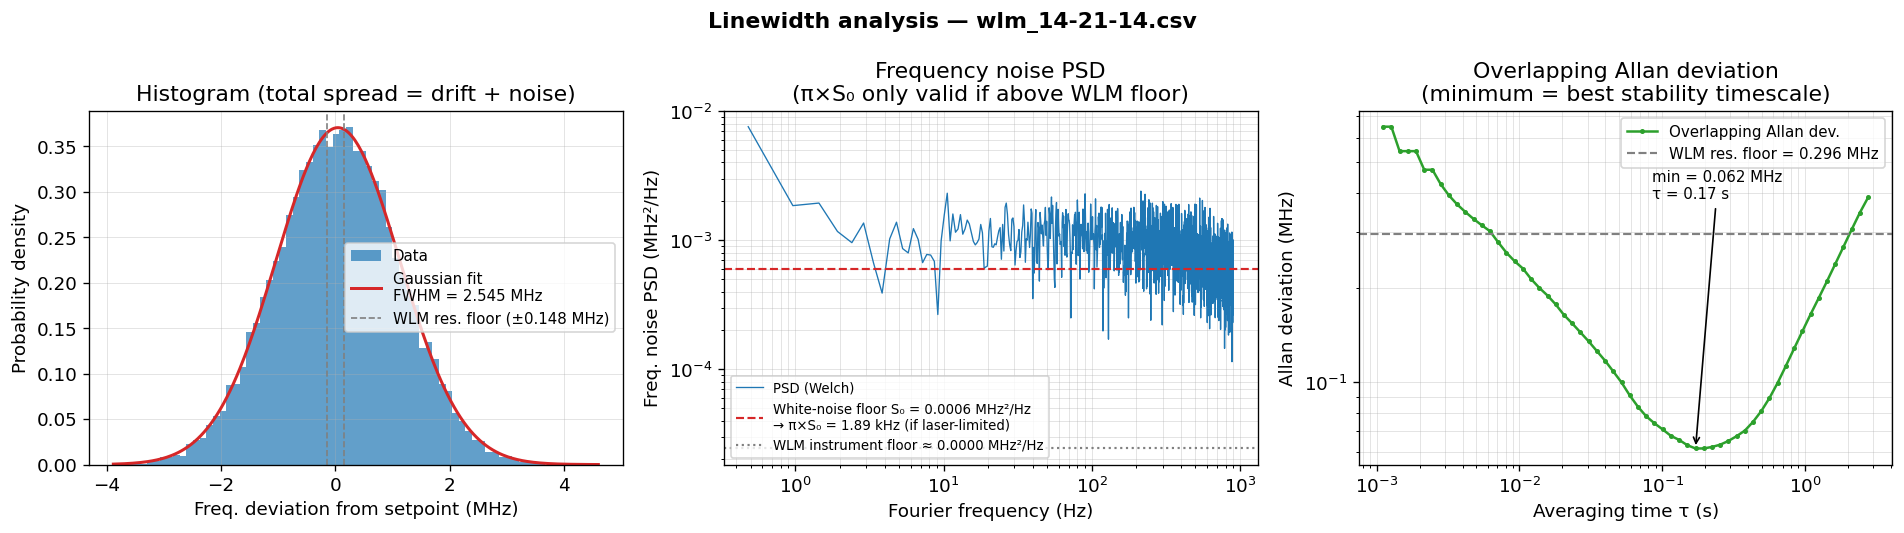


Note: to resolve a kHz-level intrinsic linewidth you need a sample rate >> linewidth,
      i.e. >> ~1 kHz. Current rate is 1799.8 Hz — Lorentzian estimate is likely WLM-limited.


In [16]:
from scipy.optimize import curve_fit

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 4.5))
fig2.suptitle(f"Linewidth analysis — {os.path.basename(LOG_FILE)}", fontweight="bold")

# ── Panel 1: frequency histogram + Gaussian fit ───────────────────────────────
ax = axes2[0]
counts, bin_edges, _ = ax.hist(y_MHz, bins="auto", density=True,
                                color="#1f77b4", alpha=0.7, label="Data")
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

def gaussian(x, mu, sigma, A):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

try:
    p0 = [y_MHz.mean(), y_MHz.std(), counts.max()]
    popt, _ = curve_fit(gaussian, bin_centres, counts, p0=p0)
    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 300)
    ax.plot(x_fit, gaussian(x_fit, *popt), color="#d62728", linewidth=1.8,
            label=f"Gaussian fit\nFWHM = {2.3548*abs(popt[1]):.3f} MHz")
except Exception:
    pass

ax.axvline(wlm_res_MHz / 2, color="gray", linestyle="--", linewidth=1, label=f"WLM res. floor (±{wlm_res_MHz/2:.3f} MHz)")
ax.axvline(-wlm_res_MHz / 2, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel(y_label)
ax.set_ylabel("Probability density")
ax.set_title("Histogram (total spread = drift + noise)")
ax.legend(fontsize=9)
ax.grid(True, linewidth=0.4, alpha=0.5)

# ── Panel 2: PSD ──────────────────────────────────────────────────────────────
ax2 = axes2[1]
ax2.loglog(freqs, psd, color="#1f77b4", linewidth=0.8, label="PSD (Welch)")
ax2.axhline(S0, color="#d62728", linestyle="--", linewidth=1.3,
            label=f"White-noise floor S₀ = {S0:.4f} MHz²/Hz\n→ π×S₀ = {lorentzian_MHz*1e3:.2f} kHz (if laser-limited)")

# WLM noise floor estimate: σ²/(fs/2)
wlm_psd_floor = (wlm_res_MHz / 2) ** 2 / (fs / 2)
ax2.axhline(wlm_psd_floor, color="gray", linestyle=":", linewidth=1.3,
            label=f"WLM instrument floor ≈ {wlm_psd_floor:.4f} MHz²/Hz")

ax2.set_xlabel("Fourier frequency (Hz)")
ax2.set_ylabel("Freq. noise PSD (MHz²/Hz)")
ax2.set_title("Frequency noise PSD\n(π×S₀ only valid if above WLM floor)")
ax2.legend(fontsize=8)
ax2.grid(True, which="both", linewidth=0.4, alpha=0.5)

# Annotate if instrument-limited
if S0 < 3 * wlm_psd_floor:
    ax2.text(0.05, 0.08, "⚠ Floor is instrument-limited\nnot laser noise",
             transform=ax2.transAxes, fontsize=9, color="gray",
             bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"))

# ── Panel 3: Allan deviation ──────────────────────────────────────────────────
ax3 = axes2[2]
if len(ad) > 1:
    ax3.loglog(ad[:, 0], ad[:, 1], color="#2ca02c", linewidth=1.5, marker=".", markersize=4,
               label="Overlapping Allan dev.")
    ax3.axhline(wlm_res_MHz, color="gray", linestyle="--", linewidth=1.3,
                label=f"WLM res. floor = {wlm_res_MHz:.3f} MHz")
    imin = ad[:, 1].argmin()
    ax3.annotate(f"min = {ad[imin,1]:.3f} MHz\nτ = {ad[imin,0]:.2f} s",
                 xy=(ad[imin, 0], ad[imin, 1]), xytext=(0.55, 0.75),
                 textcoords="axes fraction", fontsize=9,
                 arrowprops=dict(arrowstyle="->", color="black"))
    ax3.legend(fontsize=9)
else:
    ax3.text(0.5, 0.5, "Not enough data\nfor Allan deviation\n(need longer run)",
             ha="center", va="center", transform=ax3.transAxes, fontsize=11, color="gray")
ax3.set_xlabel("Averaging time τ (s)")
ax3.set_ylabel("Allan deviation (MHz)")
ax3.set_title("Overlapping Allan deviation\n(minimum = best stability timescale)")
ax3.grid(True, which="both", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.show()
print()
print("Note: to resolve a kHz-level intrinsic linewidth you need a sample rate >> linewidth,")
print(f"      i.e. >> ~1 kHz. Current rate is {fs:.1f} Hz — Lorentzian estimate is likely WLM-limited.")

## Section 7 — Lock log analysis (frequency + error signal)

Loads the most recent `lock_*.csv` produced by `lock.py --log` and plots frequency and error signal over time.

In [ ]:
import glob, os, pandas as pd, numpy as np, matplotlib.pyplot as plt

# Auto-find most recent lock log; or set manually:
# LOCK_FILE = "logs/2026-05-21/lock_14-32-05.csv"
lock_files = sorted(glob.glob("logs/**/lock_*.csv", recursive=True))
if not lock_files:
    raise FileNotFoundError("No lock_*.csv found. Run: python lock.py --setpoint ... --dry-run --debug --log")
LOCK_FILE = lock_files[-1]
print(f"Loading: {LOCK_FILE}")

lk = pd.read_csv(LOCK_FILE)
print(f"  {len(lk)} samples   duration {lk['time_s'].iloc[-1]:.1f} s   "
      f"mean rate {len(lk)/lk['time_s'].iloc[-1]:.2f} Hz")

# Try to find matching raw WLM log (same timestamp, prefix raw_)
raw_path = LOCK_FILE.replace("lock_", "raw_")
if os.path.isfile(raw_path):
    raw = pd.read_csv(raw_path)
    print(f"Raw log : {raw_path}  ({len(raw):,} samples, "
          f"{len(raw)/lk['time_s'].iloc[-1]:.0f} Hz avg)")
else:
    raw = None
    print("No raw_*.csv found alongside lock log — overlay unavailable.")

lk.head(3)


Loading: logs/2026-05-22/lock_14-21-29.csv
  22 samples   duration 42.2 s   mean rate 0.52 Hz


,time_s,frequency_THz,error_MHz,integrator_V,output_V,saturated
0,0.0000,298.004399,-0.5579,-0.002232,-0.002510,0
1,2.0090,298.004399,-0.6514,-0.004849,-0.005175,0
2,4.0178,298.004399,-0.6216,-0.007346,-0.007657,0


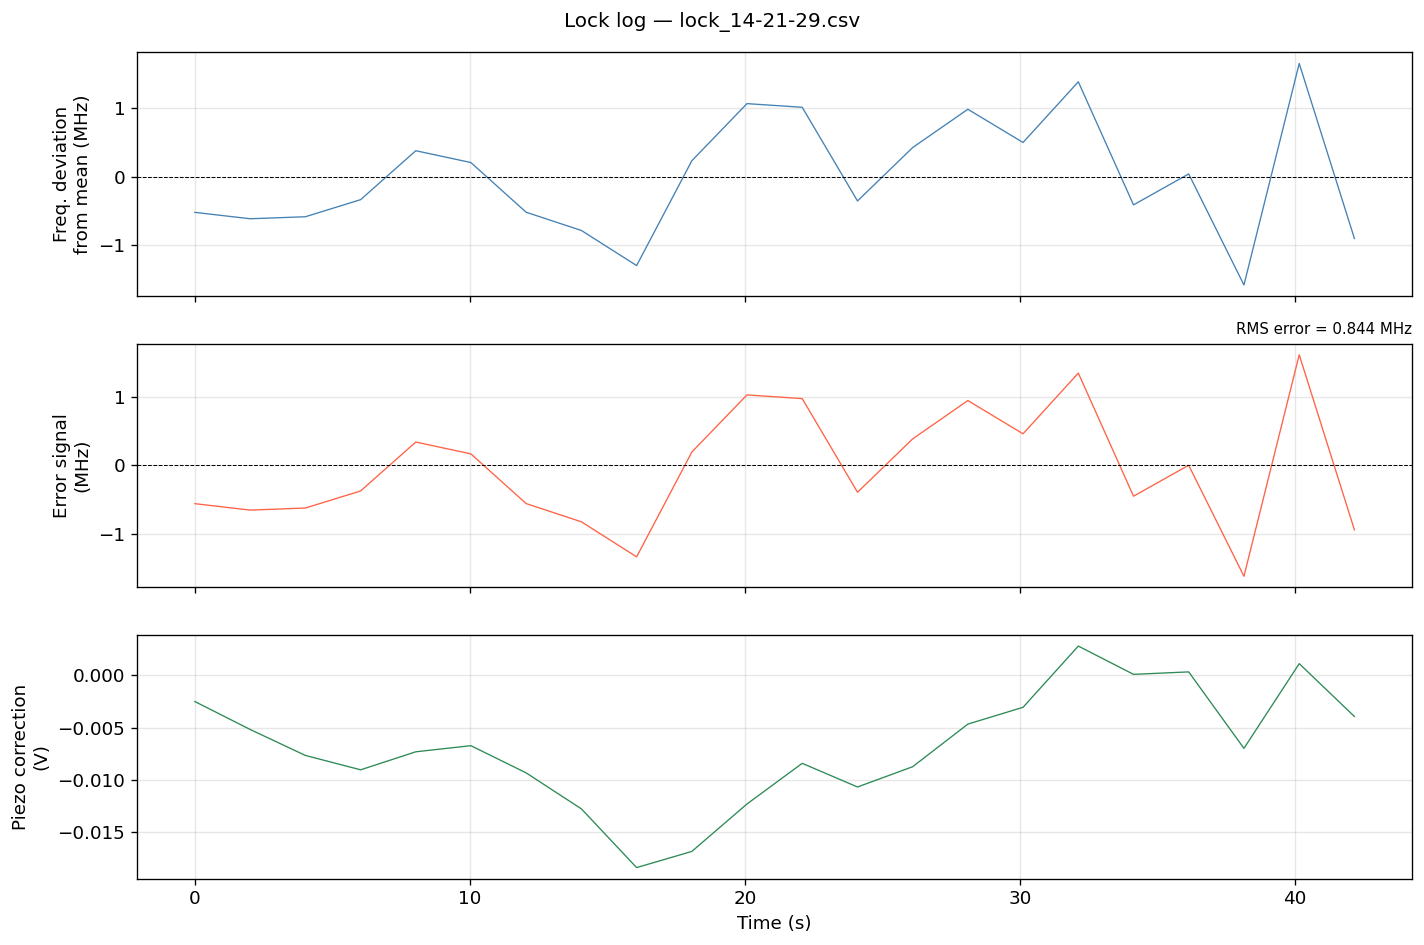

In [ ]:
t   = lk["time_s"].to_numpy()
f   = lk["frequency_THz"].to_numpy()
e   = lk["error_MHz"].to_numpy()
V   = lk["output_V"].to_numpy()
sat = lk["saturated"].to_numpy().astype(bool)

f_mean = f.mean()   # reference for both raw and averaged traces

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle(f"Lock log — {os.path.basename(LOCK_FILE)}", fontsize=12)

# ── Panel 1: raw WLM samples + averaged PI input ─────────────────────────────
ax0 = axes[0]
if raw is not None:
    ax0.plot(raw["time_s"], (raw["frequency_THz"] - f_mean) * 1e6,
             color="steelblue", lw=0.4, alpha=0.25, label=f"Raw WLM ({len(raw):,} samples)")
ax0.plot(t, (f - f_mean) * 1e6,
         color="steelblue", lw=1.8, label="Averaged (PI input)")
ax0.axhline(0, color="k", lw=0.6, ls="--")
ax0.set_ylabel("Freq. deviation\nfrom mean (MHz)")
ax0.legend(fontsize=8, loc="upper right")
ax0.grid(True, alpha=0.3)

# ── Panel 2: error signal (setpoint − freq) ───────────────────────────────────
ax1 = axes[1]
ax1.plot(t, e, color="tomato", lw=0.8)
ax1.axhline(0, color="k", lw=0.6, ls="--")
ax1.set_ylabel("Error signal\n(MHz)")
ax1.grid(True, alpha=0.3)
rms = np.std(e)
ax1.set_title(f"RMS error = {rms:.3f} MHz", fontsize=9, loc="right")

# ── Panel 3: PI output voltage ────────────────────────────────────────────────
ax2 = axes[2]
ax2.plot(t, V, color="seagreen", lw=0.8, label="PI output")
if sat.any():
    ax2.scatter(t[sat], V[sat], color="red", s=15, zorder=5, label="saturated")
    ax2.legend(fontsize=8)
ax2.set_ylabel("Piezo correction\n(V)")
ax2.set_xlabel("Time (s)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
